<a href="https://colab.research.google.com/github/192231/Metodos-Num-ricos-I/blob/main/PuntoFijo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**Iteración de punto fijo**

Queremos resolver la ecuación $x^3+4x^2-10=0$ en el intervalo $[1,2]$

Para aplicar el método de **iteración de punto fijo** dado un problema de buscar una raíz de $f(p)=0$, podemos definir una función $g$ con un punto fijo en $p$ de muchas formas:

a) $x=g_1(x)=x-x^3-4x^2+10$  
b) $x=g_2(x)=(\frac{10}{x}-4x)^\frac{1}{2}$  
c) $x=g_3(x)=\frac{1}{2}(10-x^3)^\frac{1}{2}$  
d) $x=g_4(x)=(\frac{10}{4+x})^\frac{1}{2}$  
e) $x=g_5(x)=x-\frac{x^3+4x^2-10}{3x^2+8x}$

Como éstas hay infinidad de $g_n(x)$. Para saber cual $g(x)$ usar, evaluamos cada una de ellas en el intervalo $[1,2]$ para ver si safisfacen el *Teorema del valor intermedio* y que a su vez $∈ [1,2]$. Veamos por qué son condiciones suficientes pero no necesarias:

a) $g_1(1)=6$ &emsp;&emsp; $g_1(2)=-12$  
*No cumple porque aunque hay una raíz en $[1,2]$, no hay un punto fijo puesto que $g_1(1)∉ [1,2]$ y $g_1(2)∉ [1,2]$*.

b) $g_2(1)=2.449489743$ &emsp;&emsp; $g_2(2)=(-3)^\frac{1}{2}$  
*No cumple ya que $g_1(1)$ da como resultado un número imaginario y a demás esta fuera del intervalo*.

c) $g_3(1)=1.5$  &emsp;&emsp; $g_3(2)=0.7$  
*Aunque no cumple ya que $g_3(2)∉ [1,2]$ funciona porque una raíz real es x=1.36523001341 y si está dentro de [1,2] y a demás al calcular la derivada de $g'_3(x)$ y evaluarla en esa raíz se obtiene que $|g'_3(x)|=0.51196125503<1$ esto demuestra que es un punto fijo.*


d) $g_4(1)=1.414213562$ &emsp;&emsp; $g_4(2)=1.290994449$  
*Si cumple ya que $g_4(1)$ , $g_4(2)∈ [1,2]$*.

e) $g_5(1)=1.45454545455$   &emsp;&emsp; $g_5(2)=1.5$  
*Si Si cumple ya que $g_5(1)$ , $g_5(2)∈ [1,2]$*.

En este caso ocuparemos: $g_3(x)=\frac{1}{2}(10-x^3)^\frac{1}{2}$

Importamos las librerías numpy, que tiene funciones matemáticas, matplotlib que permite gráficas, pandas que nos permite estructurar los datos y tabulate para darles formato.

In [35]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tabulate import tabulate

Definimos la función  $g(x)$  asociada a la ecuación $x=g(x)$

In [36]:
def g(x):
    return 0.5*np.sqrt(10.0-x**3)

*Gráfica:*

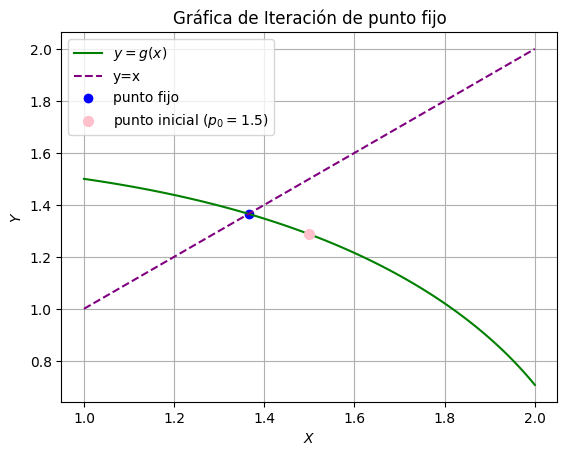

In [37]:
x=np.linspace(1,2,100) #genera una reticula o una partición.
y_g=[g(val) for val in x]
plt.plot(x,y_g,color='green',label='$y=g(x)$')
plt.plot(x,x,label='y=x',color='purple',linestyle='--')
plt.title("Gráfica de Iteración de punto fijo")
plt.xlabel("$X$")
plt.ylabel("$Y$")
p=1.36523001
plt.scatter(p,p,color='blue',label='punto fijo')
p0=1.5
plt.scatter(p0, g(p0), color='pink', s=50, zorder=5, label='punto inicial ($p_0 = 1.5$)')
plt.legend()
plt.grid(True)
plt.show()

In [38]:
def pfijo(p0,tol, max_i):
    resultados=[]
    exito=False

    for i in range(1, max_i +1):
        p=g(p0)
        error=np.abs(p-p0)
        resultados.append({'n': i, 'p_n': p, 'Error': error})

        if error<tol:
            exito=True
            break

        p0=p

    df=pd.DataFrame(resultados)

    print("Iteración de Punto Fijo:")
    print(tabulate(df, headers='keys', tablefmt='fancy_grid', showindex=False, floatfmt=".8f"))

    if exito:
        print(f"\nProcedimiento completado con éxito. La raíz aproximada es: {p:.8f}")
    else:
        print(f"\nEl método fracasó después de {max_i} iteraciones.")

In [39]:
pfijo(0.5, 0.00001, 15)

Iteración de Punto Fijo:
╒═════════════╤════════════╤════════════╕
│           n │        p_n │      Error │
╞═════════════╪════════════╪════════════╡
│  1.00000000 │ 1.57122564 │ 1.07122564 │
├─────────────┼────────────┼────────────┤
│  2.00000000 │ 1.23703645 │ 0.33418919 │
├─────────────┼────────────┼────────────┤
│  3.00000000 │ 1.42364090 │ 0.18660445 │
├─────────────┼────────────┼────────────┤
│  4.00000000 │ 1.33366328 │ 0.08997762 │
├─────────────┼────────────┼────────────┤
│  5.00000000 │ 1.38092989 │ 0.04726662 │
├─────────────┼────────────┼────────────┤
│  6.00000000 │ 1.35707514 │ 0.02385475 │
├─────────────┼────────────┼────────────┤
│  7.00000000 │ 1.36937381 │ 0.01229867 │
├─────────────┼────────────┼────────────┤
│  8.00000000 │ 1.36310044 │ 0.00627337 │
├─────────────┼────────────┼────────────┤
│  9.00000000 │ 1.36631814 │ 0.00321770 │
├─────────────┼────────────┼────────────┤
│ 10.00000000 │ 1.36467238 │ 0.00164576 │
├─────────────┼────────────┼────────────┤
│ 11.0000